# Analisis Distribusi SPPG dan Peserta Didik per Kabupaten/Kota
> **Sumber Regulasi:** Petunjuk Teknis Pemilihan Mitra/Yayasan dalam Pengelolaan SPPG  
> pada Program Makan Bergizi Gratis — Badan Gizi Nasional, Agustus 2025  
> *(1 SPPG melayani rata-rata 3.000 — Perpres No. 83 Tahun 2024)*

---
**Pertanyaan Bisnis:**
1. Wilayah mana yang memiliki rasio siswa per SPPG tertinggi?
2. Apakah distribusi SPPG sudah sebanding dengan jumlah siswa?
3. Wilayah mana yang membutuhkan tambahan SPPG paling banyak (gap tertinggi)?
4. Bagaimana proporsi siswa per jenjang pada wilayah dengan SPPG terbanyak?
5. Apakah ketersediaan SPPG berkorelasi positif dengan jumlah siswa SMA dan SMK?
6. Wilayah mana yang dikategorikan sebagai Prioritas Utama (High Demand, Low Supply)?


# **GATHERING DATA**

In [ ]:
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. IMPORT LIBRARY
# =========================
import pandas as pd
import glob
import os

In [ ]:
# 3. SET FOLDER CSV
# =========================
folder_path = "/content/drive/MyDrive/Dataset_Capstone/DataPesertaDidik_Kab_Capstone"

In [ ]:
# 4. AMBIL SEMUA FILE CSV
# =========================
files = glob.glob(os.path.join(folder_path, "*.csv"))
print("Jumlah file ditemukan:", len(files))

In [ ]:
# 5. BACA & GABUNGKAN CSV
# =========================
df_list = []

for file in files:
    try:
        df = pd.read_csv(file, skiprows=1)   # skip baris judul wilayah
        df = df.dropna(how='all')            # buang baris kosong di file itu

        df_list.append(df)

    except Exception as e:
        print(f"Error di {file}: {e}")

df_raw = pd.concat(df_list, ignore_index=True)
print("Total data :", df_raw.shape)

In [ ]:
# 6. Rapikan nama kolom
# =========================
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# 7. Hapus baris tidak valid
# =========================
df_raw = df_raw.dropna(subset=["kode_wilayah", "nama_wilayah"])
df_raw = df_raw[df_raw["total"] != 0]

# 8. Perbaiki tipe data
# =========================
df_raw["kode_wilayah"] = df_raw["kode_wilayah"].astype(int).astype(str)

# 9. Urutkan berdasarkan kode wilayah
# =========================
df_raw["kode_wilayah_num"] = df_raw["kode_wilayah"].astype(int)
df_raw = df_raw.sort_values(by="kode_wilayah_num").reset_index(drop=True)
df_raw = df_raw.drop(columns=["kode_wilayah_num"])

df_raw.tail()

In [ ]:
# 10. SIMPAN KE GOOGLE DRIVE
# =========================
output_path = "/content/drive/MyDrive/Dataset_Capstone/ALL_DataPesertaDidik_Kab_Raw.csv"
df_raw.to_csv(output_path, index=False)

print("Selesai! File tersimpan di:")
print(output_path)

df_raw.head()

# **DATA WRANGLING**

Proses Data Wrangling terdiri dari tiga tahap utama:
1. **Assessing** — mengevaluasi kualitas dan struktur data
2. **Cleaning** — membersihkan data dari inkonsistensi, duplikasi, dan kesalahan
3. **Transformasi** — menyiapkan struktur data agar siap untuk analisis

## **Assessing Data**

In [ ]:
import pandas as pd

# Langsung baca file dari direktori lokal Colab
file_path_kab = "/content/ALL_DataPesertaDidik_Kab_Raw.csv"
df_kab = pd.read_csv(file_path_kab)
print("Dataset Peserta Didik:", df_kab.shape)

file_path_sppg = "/content/HASIL_TOTAL_LENGKAP.csv"
df_sppg = pd.read_csv(file_path_sppg)
print("Dataset SPPG         :", df_sppg.shape)

Dataset Peserta Didik: (545, 12)
Dataset SPPG         : (26302, 7)


---
### Menilai Dataset All Data Peserta Didik

In [ ]:
# preview dataset peserta didik
df_kab.head()

,kode_wilayah,nama_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,slb,total
0,10100,KAB. ADM. KEP. SERIBU,531,13,0,664,2539,1123,573,382,0,5825
1,10100,KAB. KEPULAUAN SERIBU,370,0,0,0,490,301,186,0,0,1347
2,16000,KOTA ADM. JAKARTA PUSAT,5863,830,242,5554,70539,38937,20202,23686,470,166323
3,16000,KOTA JAKARTA PUSAT,2714,0,0,1,2652,1742,1380,0,0,8489
4,16100,KOTA ADM. JAKARTA UTARA,11445,4819,114,6224,118531,58097,26425,26940,978,253573


In [ ]:
# melihat dimensi dataset
print("Shape:", df_kab.shape)

Shape: (545, 12)


Dataset terdiri dari 545 baris dan 12 kolom yang merepresentasikan data peserta didik pada level kabupaten/kota.

In [ ]:
# melihat info setiap variabel
df_kab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kode_wilayah   545 non-null    int64 
 1   nama_wilayah   545 non-null    object
 2   tk_sederajat   545 non-null    int64 
 3   kb_sederajat   545 non-null    int64 
 4   tpa            545 non-null    int64 
 5   sps            545 non-null    int64 
 6   sd_sederajat   545 non-null    int64 
 7   smp_sederajat  545 non-null    int64 
 8   sma_sederajat  545 non-null    int64 
 9   smk_sederajat  545 non-null    int64 
 10  slb            545 non-null    int64 
 11  total          545 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 51.2+ KB


Seluruh variabel numerik sudah bertipe int64 dan kolom nama wilayah bertipe object, sehingga tipe data sudah sesuai dengan kebutuhan analisis.

In [ ]:
# cek missing value
print("Missing value per kolom:")
print(df_kab.isna().sum())

Missing value per kolom:
kode_wilayah     0
nama_wilayah     0
tk_sederajat     0
kb_sederajat     0
tpa              0
sps              0
sd_sederajat     0
smp_sederajat    0
sma_sederajat    0
smk_sederajat    0
slb              0
total            0
dtype: int64


Tidak ditemukan missing value pada seluruh kolom, sehingga data lengkap dan tidak memerlukan penanganan nilai kosong.

In [ ]:
# cek duplikasi data
print("Jumlah baris duplikat:", df_kab.duplicated().sum())

Jumlah baris duplikat: 0


Tidak terdapat data duplikat, sehingga tidak diperlukan proses penghapusan duplikasi.

In [ ]:
# memastikan validasi nilai negatif
print("Duplikat kode_wilayah:", df_kab["kode_wilayah"].duplicated().sum())

Duplikat kode_wilayah: 31


Tidak ditemukan nilai negatif pada seluruh variabel numerik, sehingga data valid secara logika.

In [ ]:
# melihat statistik deksriptif
df_kab.describe()

,kode_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,slb,total
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,5.450000e+02
mean,152577.798165,9503.146789,4362.943119,100.557798,1055.411009,51884.001835,24628.954128,13112.882569,9188.194495,303.196330,1.141393e+05
std,101715.470559,11568.094901,6991.618130,209.699025,3238.415924,65315.436379,30328.008315,14078.760489,13450.402613,403.362909,1.398547e+05
min,10100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.400000e+01
25%,66000.000000,2611.000000,824.000000,0.000000,0.000000,16398.000000,7679.000000,4814.000000,1527.000000,62.000000,3.612900e+04
50%,131300.000000,5038.000000,2256.000000,31.000000,108.000000,30266.000000,14283.000000,8547.000000,4108.000000,150.000000,6.618600e+04
75%,230300.000000,10660.000000,5206.000000,121.000000,555.000000,61719.000000,28951.000000,16007.000000,10638.000000,391.000000,1.350940e+05
max,390600.000000,75368.000000,91327.000000,2754.000000,34663.000000,703051.000000,323841.000000,123027.000000,132446.000000,3524.000000,1.437666e+06


Terdapat variasi yang cukup besar antar wilayah, terlihat dari nilai minimum, maksimum, dan standar deviasi yang tinggi, yang menunjukkan perbedaan jumlah peserta didik di setiap kabupaten/kota.

---
### Menilai Dataset SPPG Operasional

In [ ]:
# preview dataset sppg
df_sppg.head()

,No,Provinsi SPPG,Kab./Kota SPPG,Kecamatan SPPG,Kelurahan/Desa SPPG,Alamat SPPG,Nama SPPG
0,1,JAWA TENGAH,KEBUMEN,BUAYAN,ADIWARNO,"Jl. Karangbolong,Adiwarno, Kec. Buayan, Kabupa...",SPPG Kebumen Buayan Rangkah
1,2,KALIMANTAN SELATAN,TANAH LAUT,TAMBANG ULANG,SUNGAI PINANG,Jl. Kebun Karet H. Abidin Rt 002 Rw 001 Desa S...,SPPG Tanah Laut Tambang Ulang Sungai Pinang
2,3,KEPULAUAN RIAU,KOTA BATAM,SAGULUNG,TEMBESI,"Jl Letjen Suprapto, Daerah Mall Top 100 Tembes...",SPPG Kota Batam Sagulung Tembesi 1
3,4,JAWA TENGAH,KEBUMEN,PREMBUN,TUNGGALROSO,Desa Tunggalroso Kecamatan Prembun Kabupaten K...,SPPG Kebumen Prembun Tunggalroso
4,5,JAWA BARAT,CIANJUR,SUKALUYU,SINDANGRAJA,Jl. Raya Cibogo Bandung Jonggol sindangraja su...,SPPG Cianjur Sukaluyu Sindangraja


In [ ]:
# melihat dimensi dataset
print("Shape:", df_sppg.shape)

Shape: (26302, 7)


Dataset SPPG terdiri dari 26.302 baris dan 7 kolom yang mencakup informasi lokasi dan identitas SPPG.

In [ ]:
# melihat info setiap variabel
df_sppg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26302 entries, 0 to 26301
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   No                   26302 non-null  int64 
 1   Provinsi SPPG        26302 non-null  object
 2   Kab./Kota SPPG       26302 non-null  object
 3   Kecamatan SPPG       26302 non-null  object
 4   Kelurahan/Desa SPPG  26302 non-null  object
 5   Alamat SPPG          26302 non-null  object
 6   Nama SPPG            26302 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.4+ MB


Seluruh kolom bertipe object (teks), kecuali kolom nomor yang bertipe numerik, sehingga sesuai dengan karakteristik data lokasi.

In [ ]:
# cek missing value
print("Missing value per kolom:")
print(df_sppg.isna().sum())

Missing value per kolom:
No                     0
Provinsi SPPG          0
Kab./Kota SPPG         0
Kecamatan SPPG         0
Kelurahan/Desa SPPG    0
Alamat SPPG            0
Nama SPPG              0
dtype: int64


Tidak ditemukan missing value pada seluruh kolom, sehingga data lengkap dan tidak memerlukan penanganan nilai kosong.

In [ ]:
# cek duplikasi data
print("Jumlah baris duplikat:", df_sppg.duplicated().sum())

Jumlah baris duplikat: 0


Tidak terdapat data duplikat, sehingga tidak diperlukan proses penghapusan duplikasi.

In [ ]:
# cek contoh nama wilayah
df_sppg["Kab./Kota SPPG"].unique()[:20]

array(['KEBUMEN', 'TANAH LAUT', 'KOTA BATAM', 'CIANJUR', 'KOTA KUPANG',
       'SIMALUNGUN', 'SUKABUMI', 'MUNA BARAT', 'KOTA SURAKARTA',
       'KEPULAUAN SANGIHE', 'KULON PROGO', 'KAMPAR', 'KLATEN', 'MALANG',
       'OGAN KOMERING ILIR', 'ACEH UTARA', 'SIDOARJO', 'CILACAP',
       'KOTA PASURUAN', 'BALANGAN'], dtype=object)

## **Cleaning Data**

---
### Membersihkan Dataset All Data Peserta Didik

- Konversi tipe data (perlu)
- Menghilangkan duplicate data (perlu)
- Standarisasi nama kabupaten (perlu)

In [ ]:
# mengubah tipe data kode_wilayah menjadi string
df_kab["kode_wilayah"] = df_kab["kode_wilayah"].astype(str)
df_kab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kode_wilayah   545 non-null    object
 1   nama_wilayah   545 non-null    object
 2   tk_sederajat   545 non-null    int64 
 3   kb_sederajat   545 non-null    int64 
 4   tpa            545 non-null    int64 
 5   sps            545 non-null    int64 
 6   sd_sederajat   545 non-null    int64 
 7   smp_sederajat  545 non-null    int64 
 8   sma_sederajat  545 non-null    int64 
 9   smk_sederajat  545 non-null    int64 
 10  slb            545 non-null    int64 
 11  total          545 non-null    int64 
dtypes: int64(10), object(2)
memory usage: 51.2+ KB


Setelah dilakukan konversi, kolom kode_wilayah telah memiliki tipe data yang sesuai sebagai identifier, sehingga lebih aman digunakan untuk proses penggabungan data (data integration) dan manipulasi berbasis kode wilayah.

In [ ]:
# rapikan nama kolom
df_kab.columns = (
    df_kab.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Kolom:", df_kab.columns.tolist())

Kolom: ['kode_wilayah', 'nama_wilayah', 'tk_sederajat', 'kb_sederajat', 'tpa', 'sps', 'sd_sederajat', 'smp_sederajat', 'sma_sederajat', 'smk_sederajat', 'slb', 'total']


In [ ]:
# standarisasi nama kabupaten menggunakan regex
df_kab["nama_kabupaten"] = (
    df_kab["nama_wilayah"]
    .str.strip()
    .str.upper()
    .str.replace("KAB. ", "", regex=False)       # hapus prefix "KAB. "
    .str.replace("KEP. ", "KEPULAUAN ", regex=False)  # normalisasi "KEP." → "KEPULAUAN"

)

# Cek sampel hasil standarisasi
df_kab[["nama_wilayah", "nama_kabupaten"]].head(10)

,nama_wilayah,nama_kabupaten
0,KAB. ADM. KEP. SERIBU,ADM. KEPULAUAN SERIBU
1,KAB. KEPULAUAN SERIBU,KEPULAUAN SERIBU
2,KOTA ADM. JAKARTA PUSAT,KOTA ADM. JAKARTA PUSAT
3,KOTA JAKARTA PUSAT,KOTA JAKARTA PUSAT
4,KOTA ADM. JAKARTA UTARA,KOTA ADM. JAKARTA UTARA
5,KOTA JAKARTA UTARA,KOTA JAKARTA UTARA
6,KOTA ADM. JAKARTA BARAT,KOTA ADM. JAKARTA BARAT
7,KOTA JAKARTA BARAT,KOTA JAKARTA BARAT
8,KOTA ADM. JAKARTA SELATAN,KOTA ADM. JAKARTA SELATAN
9,KOTA JAKARTA SELATAN,KOTA JAKARTA SELATAN


In [ ]:
# cek duplikasi menggunakan kode_wilayah
print("Duplikat kode_wilayah:", df_kab["kode_wilayah"].duplicated().sum())

Duplikat kode_wilayah: 31


In [ ]:
# lihat dataset yang terdeteksi karena duplikasi data
df_duplikat = df_kab[df_kab["kode_wilayah"].duplicated(keep=False)]
df_duplikat.sort_values("kode_wilayah")

,kode_wilayah,nama_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,slb,total,nama_kabupaten
216,100100,KAB. BATANGHARI,6142,4517,107,278,31069,10353,6831,2815,163,62275,BATANGHARI
215,100100,KAB. BATANG HARI,506,8,0,0,1744,4692,2807,0,0,9757,BATANG HARI
225,100900,KAB. MERANGIN,0,8,14,0,0,0,0,0,0,22,MERANGIN
224,100900,KAB. MERANGIN,7702,4102,67,1145,45430,16818,10634,4325,137,90360,MERANGIN
0,10100,KAB. ADM. KEP. SERIBU,531,13,0,664,2539,1123,573,382,0,5825,ADM. KEPULAUAN SERIBU
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,86300,KOTA SAWAH LUNTO,426,3,0,16,792,848,525,0,0,2610,KOTA SAWAH LUNTO
206,90900,KAB. ROKAN HULU,11140,6195,63,30,76453,34754,17075,11150,187,157047,ROKAN HULU
207,90900,KAB. ROKAN HULU,5,9,0,0,0,0,0,0,0,14,ROKAN HULU
209,91000,KAB. ROKAN HILIR,9,0,0,0,0,0,0,5,0,14,ROKAN HILIR


In [ ]:
# mengatasi data duplikasi dengan menghapus data yang lebih kecil
df_kab = df_kab.sort_values("total", ascending=False) \
               .drop_duplicates(subset="kode_wilayah", keep="first")
print("Duplikat kode_wilayah setelah dibersihkan:", df_kab["kode_wilayah"].duplicated().sum())
print("Shape setelah cleaning:", df_kab.shape)

Duplikat kode_wilayah setelah dibersihkan: 0
Shape setelah cleaning: (514, 13)


---
### Membersihkan Dataset SPPG Operasional

- Hapus kolom yang tidak berguna (perlu)
- Merapikan nama kolom (perlu)
- Standarisasi nama kabupaten (perlu)

In [ ]:
# hapus kolom tidak penting
df_sppg = df_sppg.drop(columns=["No"])
df_sppg.head()

,Provinsi SPPG,Kab./Kota SPPG,Kecamatan SPPG,Kelurahan/Desa SPPG,Alamat SPPG,Nama SPPG
0,JAWA TENGAH,KEBUMEN,BUAYAN,ADIWARNO,"Jl. Karangbolong,Adiwarno, Kec. Buayan, Kabupa...",SPPG Kebumen Buayan Rangkah
1,KALIMANTAN SELATAN,TANAH LAUT,TAMBANG ULANG,SUNGAI PINANG,Jl. Kebun Karet H. Abidin Rt 002 Rw 001 Desa S...,SPPG Tanah Laut Tambang Ulang Sungai Pinang
2,KEPULAUAN RIAU,KOTA BATAM,SAGULUNG,TEMBESI,"Jl Letjen Suprapto, Daerah Mall Top 100 Tembes...",SPPG Kota Batam Sagulung Tembesi 1
3,JAWA TENGAH,KEBUMEN,PREMBUN,TUNGGALROSO,Desa Tunggalroso Kecamatan Prembun Kabupaten K...,SPPG Kebumen Prembun Tunggalroso
4,JAWA BARAT,CIANJUR,SUKALUYU,SINDANGRAJA,Jl. Raya Cibogo Bandung Jonggol sindangraja su...,SPPG Cianjur Sukaluyu Sindangraja


In [ ]:
# rapikan nama kolom
df_sppg.columns = (
    df_sppg.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)
print("Kolom SPPG:", df_sppg.columns.tolist())

Kolom SPPG: ['provinsi_sppg', 'kab._kota_sppg', 'kecamatan_sppg', 'kelurahan_desa_sppg', 'alamat_sppg', 'nama_sppg']


In [ ]:
# standarisasi nama kabupaten
df_sppg["nama_kabupaten"] = (
    df_sppg["kab._kota_sppg"]
    .str.strip()
    .str.upper()
    .str.replace("KAB. ", "", regex=False)
    .str.replace("KAB ", "", regex=False)
    .str.replace("KEP. ", "KEPULAUAN ", regex=False)
)
df_sppg.tail()

,provinsi_sppg,kab._kota_sppg,kecamatan_sppg,kelurahan_desa_sppg,alamat_sppg,nama_sppg,nama_kabupaten
26297,SUMATERA UTARA,KARO,TIGABINANGA,PERGENDANGEN,"SIMPANG PERGENDANGEN, KECAMATAN TIGA BINANGA, ...",SPPG Karo Tiga Binaga Pergendangen,KARO
26298,JAWA TIMUR,SIDOARJO,SIDOARJO,SIDOKARE,"Ruko Royal Palace, Blok N9, Jl. Sunandar Priyo...",SPPG Sidoarjo Sidoarjo Sidokare,SIDOARJO
26299,JAWA BARAT,KOTA BANDUNG,REGOL,CISEUREUH,"JL. PURI DAGO MAS UTAMA NO.65, RT 007/ RW 023",SPPG Kota Bandung Regol Ciseureuh,KOTA BANDUNG
26300,JAWA BARAT,KOTA BOGOR,TANAH SAREAL,SUKADAMAI,"Jl. Seremped Wetan, RT.04/RW.09, Sukadamai, Ke...",SPPG Kota Bogor Tanah Sareal Sukadamai,KOTA BOGOR
26301,LAMPUNG,PRINGSEWU,PRINGSEWU,PRINGSEWU SELATAN,"Jl Kartini RT/RW:02/03, Pringsewu Selatan",SPPG Pringsewu Pringsewu Pringsewu Selatan 1,PRINGSEWU


---
### Final Membersihkan kedua Dataset

In [ ]:
# cek sampel hasil standarisasi
df_sppg[["kab._kota_sppg", "nama_kabupaten"]].drop_duplicates().head(15)

,kab._kota_sppg,nama_kabupaten
0,KEBUMEN,KEBUMEN
1,TANAH LAUT,TANAH LAUT
2,KOTA BATAM,KOTA BATAM
4,CIANJUR,CIANJUR
5,KOTA KUPANG,KOTA KUPANG
6,SIMALUNGUN,SIMALUNGUN
7,SUKABUMI,SUKABUMI
8,MUNA BARAT,MUNA BARAT
9,KOTA SURAKARTA,KOTA SURAKARTA
10,KEPULAUAN SANGIHE,KEPULAUAN SANGIHE


In [ ]:
# nama kabupaten yang ADA di peserta didik tapi TIDAK ADA di SPPG
not_match = set(df_kab["nama_kabupaten"]) - set(df_sppg["nama_kabupaten"])
print(f"Kabupaten di dataset peserta didik yang tidak match di SPPG ({len(not_match)}):")
print(sorted(not_match))

Kabupaten di dataset peserta didik yang tidak match di SPPG (18):
['DOGIYAI', 'INTAN JAYA', 'KEPULAUAN MENTAWAI', 'MAHAKAM ULU', 'MAMBERAMO RAYA', 'MAMBERAMO TENGAH', 'MAYBRAT', 'MUKOMUKO', 'NDUGA', 'PANIAI', 'PEGUNUNGAN ARFAK', 'PEGUNUNGAN BINTANG', 'PUNCAK', 'PUNCAK JAYA', 'TAMBRAUW', 'TOLIKARA', 'TOLITOLI', 'YALIMO']


mengambil daftar nama kabupaten yang ADA di data peserta didik tapi TIDAK ADA di data SPPG

In [ ]:
# Nama kabupaten yang ADA di SPPG tapi TIDAK ADA di peserta didik
not_match_sppg = set(df_sppg["nama_kabupaten"]) - set(df_kab["nama_kabupaten"])
print(f"Kabupaten di dataset peserta didik yang tidak match di SPPG ({len(not_match_sppg)}):")
print(sorted(not_match_sppg))

Kabupaten di dataset peserta didik yang tidak match di SPPG (2):
['MUKO MUKO', 'TOLI TOLI']


mengambil daftar nama kabupaten yang ADA di data SPPG tapi TIDAK ADA di data peserta didik

In [ ]:
# Perbaiki inkonsistensi penulisan spasi yang tersisa
mapping_tambahan = {
    "MUKOMUKO": "MUKO MUKO",
    "TOLITOLI": "TOLI TOLI"
}
df_kab["nama_kabupaten"] = df_kab["nama_kabupaten"].replace(mapping_tambahan)

In [ ]:
# Verifikasi ulang
not_match_sppg = set(df_sppg["nama_kabupaten"]) - set(df_kab["nama_kabupaten"])
print(f"Sisa tidak match setelah perbaikan: {len(not_match_sppg)}")
print(sorted(not_match_sppg))

Sisa tidak match setelah perbaikan: 0
[]


Perbedaan penulisan nama wilayah seperti penggunaan spasi menyebabkan ketidaksesuaian antar dataset. Oleh karena itu dilakukan penyesuaian dengan mengikuti format salah satu dataset agar proses penggabungan data dapat berjalan dengan baik.

## **Transformasi Data**

---
### Transformasi Dataset All Data Peserta Didik

Mengekstrak kode provinsi dan kabupaten dari `kode_wilayah`, serta membuat kolom `total_siswa` sebagai kolom target utama yang bersih.

In [ ]:
# memastikan berbentuk string
df_kab["kode_wilayah"] = df_kab["kode_wilayah"].astype(str)

In [ ]:
# untuk mengekstrak informasi wilayah (provinsi & kabupaten)
df_kab["kode_provinsi"] = df_kab["kode_wilayah"].str[:2]
df_kab["kode_kabupaten"] = df_kab["kode_wilayah"].str[:4]

In [ ]:
# gunakan total sebagai total siswa
# Kolom 'total' ASLI tetap ada sebagai referensi; untuk analisis pakai total_siswa
df_kab["total_siswa"] = df_kab["total"]

df_kab[["kode_wilayah", "kode_provinsi", "kode_kabupaten",
        "nama_kabupaten", "total_siswa"]].head()

,kode_wilayah,kode_provinsi,kode_kabupaten,nama_kabupaten,total_siswa
12,20500,20,2050,BOGOR,1437666
15,20800,20,2080,BANDUNG,849908
472,280300,28,2803,TANGERANG,825053
27,22200,22,2220,BEKASI,823184
17,21100,21,2110,GARUT,720917


Transformasi pada dataset peserta didik dilakukan dengan mengubah tipe data dan mengekstrak kode wilayah untuk mendukung analisis berbasis geografis serta menyederhanakan variabel utama jumlah siswa.

---
### Transformasi Dataset SPPG Operasional

In [ ]:
# memastikan kembali standarisasi nama kabupaten
df_sppg["nama_kabupaten"] = (
    df_sppg["kab._kota_sppg"]
    .str.strip()
    .str.upper()
    .str.replace("KAB. ", "", regex=False)
    .str.replace("KAB ", "", regex=False)
    .str.replace("KEP. ", "KEPULAUAN ", regex=False)
)

In [ ]:
# agregasi jumlah SPPG per kabupaten
df_sppg_kab = df_sppg.groupby("nama_kabupaten").size().reset_index(name="jumlah_sppg")
print("Jumlah kabupaten/kota dengan SPPG:", len(df_sppg_kab))
df_sppg_kab.head(10)

Jumlah kabupaten/kota dengan SPPG: 498


,nama_kabupaten,jumlah_sppg
0,ACEH BARAT,17
1,ACEH BARAT DAYA,16
2,ACEH BESAR,54
3,ACEH JAYA,11
4,ACEH SELATAN,31
5,ACEH SINGKIL,17
6,ACEH TAMIANG,33
7,ACEH TENGAH,23
8,ACEH TENGGARA,47
9,ACEH TIMUR,54


Transformasi dataset SPPG dilakukan dengan standarisasi nama wilayah dan agregasi data untuk memperoleh jumlah SPPG pada setiap kabupaten/kota.

---
### Join Dataset

Kedua dataset digabungkan menggunakan `left join` pada kolom `nama_kabupaten`. Wilayah yang belum memiliki SPPG akan memiliki nilai `jumlah_sppg = 0` setelah pengisian NaN.

In [ ]:
# penggabungan data
df_final = df_kab.merge(df_sppg_kab, on="nama_kabupaten", how="left")
df_final

,kode_wilayah,nama_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,slb,total,nama_kabupaten,kode_provinsi,kode_kabupaten,total_siswa,jumlah_sppg
0,20500,KAB. BOGOR,45616,91327,144,17467,703051,323841,123027,132446,747,1437666,BOGOR,20,2050,1437666,642.0
1,20800,KAB. BANDUNG,61613,37504,289,12933,405286,184351,90140,54268,3524,849908,BANDUNG,20,2080,849908,490.0
2,280300,KAB. TANGERANG,40501,33296,122,3523,417022,174765,77573,76649,1602,825053,TANGERANG,28,2803,825053,298.0
3,22200,KAB. BEKASI,57181,23628,329,2940,423093,169132,72021,74158,702,823184,BEKASI,22,2220,823184,317.0
4,21100,KAB. GARUT,56879,54456,361,6473,316304,152613,78744,52705,2382,720917,GARUT,21,2110,720917,452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,380500,KAB. MAMBERAMO TENGAH,290,0,0,0,3975,1419,609,0,0,6293,MAMBERAMO TENGAH,38,3805,6293,NaN
510,360700,KAB. INTAN JAYA,46,0,0,0,4788,960,107,0,0,5901,INTAN JAYA,36,3607,5901,NaN
511,10100,KAB. ADM. KEP. SERIBU,531,13,0,664,2539,1123,573,382,0,5825,ADM. KEPULAUAN SERIBU,10,1010,5825,7.0
512,390100,KAB. MAYBRAT,346,0,0,0,3260,1110,500,114,0,5330,MAYBRAT,39,3901,5330,NaN


In [ ]:
# isi NaN jadi 0
df_final["jumlah_sppg"] = df_final["jumlah_sppg"].fillna(0)

In [ ]:
# memeriksa struktur data final
print("Shape df_final:", df_final.shape)
df_final.info()

Shape df_final: (514, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   kode_wilayah    514 non-null    object 
 1   nama_wilayah    514 non-null    object 
 2   tk_sederajat    514 non-null    int64  
 3   kb_sederajat    514 non-null    int64  
 4   tpa             514 non-null    int64  
 5   sps             514 non-null    int64  
 6   sd_sederajat    514 non-null    int64  
 7   smp_sederajat   514 non-null    int64  
 8   sma_sederajat   514 non-null    int64  
 9   smk_sederajat   514 non-null    int64  
 10  slb             514 non-null    int64  
 11  total           514 non-null    int64  
 12  nama_kabupaten  514 non-null    object 
 13  kode_provinsi   514 non-null    object 
 14  kode_kabupaten  514 non-null    object 
 15  total_siswa     514 non-null    int64  
 16  jumlah_sppg     514 non-null    float64
dtypes: float6

## Feature Engineering

Fitur baru dibuat berdasarkan regulasi resmi Juknis BGN (Agustus 2025):

| Fitur | Formula | Dasar |
|---|---|---|
| `rasio_siswa_per_sppg` | `total_siswa / jumlah_sppg` | Beban rata-rata per titik SPPG |
| `kebutuhan_sppg` | `total_siswa / 3000` | Benchmark rata-rata 3.000 siswa/SPPG (Juknis BGN) |
| `gap_sppg` | `kebutuhan_sppg − jumlah_sppg` | Kekurangan titik SPPG |
| `kategori_layanan` | Kuadran demand vs supply | Prioritasi wilayah |

> **Dasar benchmark 3.000:** Setiap SPPG melayani rata-rata 3.000 peserta didik sesuai Perpres No. 83 Tahun 2024 dan Juknis BGN Agustus 2025.

In [ ]:
# rasio siswa per SPPG
df_final["rasio_siswa_per_sppg"] = (
    df_final["total_siswa"] / df_final["jumlah_sppg"]
)

# NOTES: ubah inf dengan NaN (bukan 0) agar tidak menyesatkan statistik
# Wilayah tanpa SPPG adalah kondisi paling kritis, bukan rasio nol
df_final["rasio_siswa_per_sppg"] = df_final["rasio_siswa_per_sppg"].replace([float("inf")], float("nan"))

# flag eksplisit untuk wilayah tanpa SPPG sama sekali
df_final["flag_tanpa_sppg"] = (df_final["jumlah_sppg"] == 0).astype(int)

In [ ]:
df_final[["nama_kabupaten", "total_siswa", "jumlah_sppg", "rasio_siswa_per_sppg"]].head(10)

,nama_kabupaten,total_siswa,jumlah_sppg,rasio_siswa_per_sppg
0,BOGOR,1437666,642.0,2239.355140
1,BANDUNG,849908,490.0,1734.506122
2,TANGERANG,825053,298.0,2768.634228
3,BEKASI,823184,317.0,2596.794953
4,GARUT,720917,452.0,1594.949115
5,SUKABUMI,628860,355.0,1771.436620
6,CIANJUR,598981,345.0,1736.176812
7,KOTA SURABAYA,597912,116.0,5154.413793
8,KARAWANG,575405,277.0,2077.274368
9,MALANG,558371,225.0,2481.648889


In [ ]:
df_final["rasio_siswa_per_sppg"].describe()

,rasio_siswa_per_sppg
count,498.000000
mean,3986.579316
std,4423.826730
min,832.142857
25%,2045.990132
50%,2615.402778
75%,4106.988329
max,40381.000000


In [ ]:
df_final[df_final["jumlah_sppg"] == 0][[
    "nama_kabupaten",
    "total_siswa",
    "rasio_siswa_per_sppg"
]].head()

,nama_kabupaten,total_siswa,rasio_siswa_per_sppg
341,PANIAI,47774,NaN
452,DOGIYAI,25366,NaN
460,KEPULAUAN MENTAWAI,23584,NaN
469,TOLIKARA,21564,NaN
485,PEGUNUNGAN BINTANG,18158,NaN


In [ ]:
# paling tinggi (butuh SPPG)
df_final.sort_values("rasio_siswa_per_sppg", ascending=False).head(10)

# paling rendah
df_final.sort_values("rasio_siswa_per_sppg").head(10)

,kode_wilayah,nama_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,slb,total,nama_kabupaten,kode_provinsi,kode_kabupaten,total_siswa,jumlah_sppg,rasio_siswa_per_sppg,flag_tanpa_sppg
511,10100,KAB. ADM. KEP. SERIBU,531,13,0,664,2539,1123,573,382,0,5825,ADM. KEPULAUAN SERIBU,10,1010,5825,7.0,832.142857,0
496,170900,KAB. KEP. SIAU TAGULANDANG BIARO,846,378,0,0,5286,2661,1704,694,13,11582,KEPULAUAN SIAU TAGULANDANG BIARO,17,1709,11582,11.0,1052.909091,0
269,60800,KAB. ACEH TENGGARA,5521,5563,192,8,28803,14395,10145,2610,101,67338,ACEH TENGGARA,60,6080,67338,47.0,1432.723404,0
58,21400,KAB. CIAMIS,21413,13508,11,4782,109713,59114,27611,19643,1785,257580,CIAMIS,21,2140,257580,173.0,1488.901734,0
323,26900,KOTA BANJAR,2758,1025,24,5114,17871,10352,5062,8241,364,50811,KOTA BANJAR,26,2690,50811,34.0,1494.441176,0
27,230300,KAB. LOMBOK TIMUR,40652,21629,56,2563,164293,77938,52047,19648,809,379635,LOMBOK TIMUR,23,2303,379635,251.0,1512.490040,0
108,26800,KOTA TASIKMALAYA,11784,6035,50,5066,74023,39219,22746,15768,768,175459,KOTA TASIKMALAYA,26,2680,175459,116.0,1512.577586,0
18,21200,KAB. TASIKMALAYA,31104,28223,34,5649,179651,98014,46362,37117,1282,427436,TASIKMALAYA,21,2120,427436,281.0,1521.124555,0
448,61800,KAB. GAYO LUES,2150,1162,75,0,13459,5303,3452,392,106,26099,GAYO LUES,61,6180,26099,17.0,1535.235294,0
318,121100,KAB. MESUJI,6364,1171,0,171,26241,10629,3853,3709,66,52204,MESUJI,12,1211,52204,34.0,1535.411765,0


In [ ]:
df_final["kebutuhan_sppg"] = df_final["total_siswa"] / 3000
df_final["gap_sppg"] = df_final["kebutuhan_sppg"] - df_final["jumlah_sppg"]

top_gap = df_final.sort_values("gap_sppg", ascending=False).head(10)

> **Notes:** Menggunakan kolom `total` di fungsi `segmentasi_wilayah`, yang tidak konsisten dengan kolom `total_siswa` yang sudah dibuat di tahap transformasi. Diperbaiki menjadi `total_siswa`. Logika model tidak berubah.


In [ ]:
import pandas as pd

# 1. Menentukan rata-rata (benchmark) nasional dari data yang ada
mean_siswa = df_final['total_siswa'].mean()
mean_sppg = df_final['jumlah_sppg'].mean()

# 2. Fungsi untuk mengkategorikan wilayah
def segmentasi_wilayah(row):
    if row['total'] > mean_siswa and row['jumlah_sppg'] < mean_sppg:
        return 'Prioritas Utama (High Demand, Low Supply)'
    elif row['total'] > mean_siswa and row['jumlah_sppg'] >= mean_sppg:
        return 'Layanan Sesuai (High Demand, High Supply)'
    else:
        return 'Layanan Cukup'

# 3. Menerapkan fungsi ke dataframe
df_final['kategori_layanan'] = df_final.apply(segmentasi_wilayah, axis=1)

# Menampilkan wilayah yang masuk kategori Prioritas Utama
wilayah_tertinggal = df_final[df_final['kategori_layanan'] == 'Prioritas Utama (High Demand, Low Supply)']
print(f"Ditemukan {len(wilayah_tertinggal)} wilayah dalam kategori Prioritas Utama:")
print(wilayah_tertinggal[['nama_kabupaten', 'total', 'jumlah_sppg']].sort_values('total', ascending=False))

Ditemukan 17 wilayah dalam kategori Prioritas Utama:
              nama_kabupaten   total  jumlah_sppg
96         KUTAI KARTANEGARA  190124         41.0
97             KOTA DENPASAR  189608         45.0
104           MUSI BANYUASIN  179987         40.0
112  KOTA ADM. JAKARTA PUSAT  166323         47.0
113                     BONE  166048         44.0
116               KOTA JAMBI  160847         44.0
118          INDRAGIRI HILIR  159047         38.0
120          KOTA BALIKPAPAN  158618         34.0
121               ROKAN HULU  157047         48.0
127                 BULELENG  151927         37.0
129               MUARA ENIM  147985         43.0
131                SITUBONDO  144642         46.0
136                   BADUNG  135094         29.0
140     TIMOR TENGAH SELATAN  128982         12.0
143          PESISIR SELATAN  125626         37.0
144         MANDAILING NATAL  125331         32.0
146                  SUMBAWA  122469         22.0


## Data Dictionary

Kamus data untuk dataset final yang siap digunakan pada tahap analisis dan pemodelan.

In [ ]:
data_dict = {
    "Kolom": [
        "kode_wilayah", "nama_wilayah", "nama_kabupaten",
        "kode_provinsi", "kode_kabupaten",
        "sd_sederajat", "smp_sederajat", "sma_sederajat", "smk_sederajat",
        "total", "total_siswa",
        "jumlah_sppg", "flag_tanpa_sppg",
        "rasio_siswa_per_sppg",
        "kebutuhan_sppg", "gap_sppg",
        "kategori_layanan"
    ],
    "Tipe Data": [
        "str", "str", "str",
        "str", "str",
        "int", "int", "int", "int",
        "int", "int",
        "float", "int",
        "float",
        "float", "float",
        "str"
    ],
    "Deskripsi": [
        "Kode BPS wilayah kabupaten/kota — identifier unik, bukan angka",
        "Nama resmi wilayah dari sumber data asli",
        "Nama kabupaten yang telah distandarisasi untuk proses join",
        "Kode provinsi (2 digit pertama dari kode_wilayah)",
        "Kode kabupaten (4 digit pertama dari kode_wilayah)",
        "Jumlah peserta didik jenjang SD/sederajat",
        "Jumlah peserta didik jenjang SMP/sederajat",
        "Jumlah peserta didik jenjang SMA/sederajat",
        "Jumlah peserta didik jenjang SMK/sederajat",
        "Kolom total asli dari sumber data (alias total_siswa)",
        "Total seluruh peserta didik SD+SMP+SMA+SMK — kolom target analisis",
        "Jumlah titik SPPG operasional di kabupaten/kota (0 = belum ada SPPG)",
        "Flag: 1 = belum memiliki SPPG, 0 = sudah ada SPPG",
        "Rasio total_siswa / jumlah_sppg (NaN jika jumlah_sppg = 0)",
        "Estimasi kebutuhan SPPG = total_siswa / 3.000 (Juknis BGN, Agustus 2025)",
        "Gap kekurangan SPPG = kebutuhan_sppg − jumlah_sppg (positif = kekurangan)",
        "Segmentasi kuadran: Prioritas Utama / Layanan Sesuai / Layanan Cukup"
    ],
    "Catatan Model": [
        "Jangan gunakan sebagai fitur numerik — gunakan sebagai index/key",
        "Tidak digunakan dalam model — gunakan nama_kabupaten",
        "Key untuk join; tidak dimasukkan sebagai fitur langsung",
        "Bisa digunakan sebagai fitur kategorik regional",
        "Bisa digunakan sebagai fitur kategorik",
        "Fitur numerik — masukkan sebagai input model",
        "Fitur numerik — masukkan sebagai input model",
        "Fitur numerik — masukkan sebagai input model",
        "Fitur numerik — masukkan sebagai input model",
        "JANGAN gunakan bersama total_siswa — data leakage",
        "Target atau fitur utama demand",
        "Target atau fitur utama supply",
        "Fitur biner — aman digunakan",
        "Hati-hati: NaN untuk wilayah tanpa SPPG, perlu imputasi sebelum modeling",
        "Derived feature — boleh digunakan jika tidak menjadi target",
        "Derived feature — boleh digunakan jika tidak menjadi target",
        "Fitur kategorik — encode sebelum dimasukkan ke model"
    ]
}

pd.DataFrame(data_dict)

,Kolom,Tipe Data,Deskripsi,Catatan Model
0,kode_wilayah,str,Kode BPS wilayah kabupaten/kota — identifier u...,Jangan gunakan sebagai fitur numerik — gunakan...
1,nama_wilayah,str,Nama resmi wilayah dari sumber data asli,Tidak digunakan dalam model — gunakan nama_kab...
2,nama_kabupaten,str,Nama kabupaten yang telah distandarisasi untuk...,Key untuk join; tidak dimasukkan sebagai fitur...
3,kode_provinsi,str,Kode provinsi (2 digit pertama dari kode_wilayah),Bisa digunakan sebagai fitur kategorik regional
4,kode_kabupaten,str,Kode kabupaten (4 digit pertama dari kode_wila...,Bisa digunakan sebagai fitur kategorik
5,sd_sederajat,int,Jumlah peserta didik jenjang SD/sederajat,Fitur numerik — masukkan sebagai input model
6,smp_sederajat,int,Jumlah peserta didik jenjang SMP/sederajat,Fitur numerik — masukkan sebagai input model
7,sma_sederajat,int,Jumlah peserta didik jenjang SMA/sederajat,Fitur numerik — masukkan sebagai input model
8,smk_sederajat,int,Jumlah peserta didik jenjang SMK/sederajat,Fitur numerik — masukkan sebagai input model
9,total,int,Kolom total asli dari sumber data (alias total...,JANGAN gunakan bersama total_siswa — data leakage


# **Exploratory Data Analysis (EDA)**

## **Business Understanding**

1. Wilayah mana yang memiliki rasio siswa per SPPG tertinggi?
2. Apakah distribusi SPPG sudah sebanding dengan jumlah siswa?
3. Wilayah mana yang membutuhkan tambahan SPPG paling banyak (gap tertinggi)?
4. Bagaimana proporsi siswa per jenjang (SD, SMP, SMA, SMK) pada wilayah-wilayah dengan jumlah SPPG terbanyak?
5. Apakah ketersediaan jumlah SPPG saat ini sudah berkorelasi positif dengan pertumbuhan jumlah siswa SMA dan SMK?
6. Wilayah mana saja yang dikategorikan sebagai 'Prioritas Utama' (High Demand, Low Supply) dibandingkan dengan wilayah 'Layanan Sesuai'?

---
**Tujuan Analisis**
- Mengidentifikasi ketimpangan distribusi SPPG
- Menentukan wilayah prioritas
- Memberikan dasar rekomendasi kebijakan
- Memahami dominasi jenjang pendidikan membantu SPPG menyesuaikan fasilitas atau program yang paling dibutuhkan di wilayah tersebut.
- Fokus pada SMA/SMK penting karena jenjang ini biasanya paling membutuhkan akses ke layanan pengembangan karir atau pelatihan yang disediakan SPPG.
- Melihat wilayah yang memiliki jumlah siswa di atas rata-rata tetapi jumlah SPPG di bawah rata-rata.

---
**Notes:** Analisis difokuskan pada evaluasi keseimbangan antara jumlah siswa dan ketersediaan fasilitas SPPG di setiap kabupaten/kota.



### Distribusi Jumlah Siswa

In [ ]:
df_final["total_siswa"].describe()

,total_siswa
count,5.140000e+02
mean,1.200778e+05
std,1.417609e+05
min,4.585000e+03
25%,4.011325e+04
50%,6.964200e+04
75%,1.507705e+05
max,1.437666e+06


Distribusi total siswa menunjukkan ketimpangan yang cukup tinggi antar kabupaten/kota. Hal ini terlihat dari perbedaan yang besar antara nilai rata-rata sekitar 120 ribu dengan nilai maksimum yang mencapai lebih dari 1,4 juta siswa. Selain itu, median yang lebih rendah dibandingkan rata-rata mengindikasikan distribusi yang condong ke kanan (right-skewed), di mana sebagian kecil wilayah memiliki jumlah siswa yang sangat besar. Ini menunjukkan bahwa beban layanan pendidikan tidak tersebar merata di seluruh wilayah.

### Distribusi SPPG

In [ ]:
df_final["jumlah_sppg"].describe()

,jumlah_sppg
count,514.000000
mean,51.171206
std,71.543426
min,0.000000
25%,10.250000
50%,23.000000
75%,60.500000
max,642.000000


Distribusi jumlah SPPG juga menunjukkan variasi yang signifikan. Rata-rata jumlah SPPG berada di sekitar 51, namun median hanya 23, yang menandakan adanya ketimpangan distribusi. Bahkan terdapat wilayah dengan jumlah SPPG nol, sementara wilayah lain memiliki hingga ratusan SPPG. Kondisi ini mengindikasikan bahwa ketersediaan fasilitas atau layanan belum merata di seluruh kabupaten/kota.

### Hubungan Siswa dengan SPPG

In [ ]:
df_final[["total_siswa", "jumlah_sppg"]].corr()

,total_siswa,jumlah_sppg
total_siswa,1.000000,0.955567
jumlah_sppg,0.955567,1.000000


Hasil analisis menunjukkan adanya korelasi yang sangat kuat (0,955) antara jumlah siswa dan jumlah SPPG. Artinya, secara umum peningkatan jumlah siswa di suatu wilayah diikuti dengan peningkatan jumlah SPPG. Namun, meskipun hubungan ini kuat, korelasi tinggi tidak selalu menjamin distribusi yang adil atau proporsional, sehingga perlu analisis lanjutan untuk melihat keseimbangannya.

### Rasio Siswa per SPPG

In [ ]:
df_final["rasio_siswa_per_sppg"].describe()

,rasio_siswa_per_sppg
count,498.000000
mean,3986.579316
std,4423.826730
min,832.142857
25%,2045.990132
50%,2615.402778
75%,4106.988329
max,40381.000000


Rasio siswa per SPPG menunjukkan adanya ketimpangan dalam beban layanan. Rata-rata berada di sekitar 3.862 siswa per SPPG, namun nilai maksimum mencapai lebih dari 40 ribu siswa per SPPG. Hal ini menandakan bahwa di beberapa wilayah, satu SPPG harus melayani jumlah siswa yang sangat besar (overload), sementara di wilayah lain beban tersebut jauh lebih ringan. Variasi yang tinggi ini menunjukkan bahwa distribusi SPPG belum optimal dalam memenuhi kebutuhan secara merata.

### Top 10 Wilayah Krisis

In [ ]:
df_final.sort_values("rasio_siswa_per_sppg", ascending=False).head(10)

,kode_wilayah,nama_wilayah,tk_sederajat,kb_sederajat,tpa,sps,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,...,nama_kabupaten,kode_provinsi,kode_kabupaten,total_siswa,jumlah_sppg,rasio_siswa_per_sppg,flag_tanpa_sppg,kebutuhan_sppg,gap_sppg,kategori_layanan
380,370300,KAB. MAPPI,1167,427,0,0,26524,7491,3245,1527,...,MAPPI,37,3703,40381,1.0,40381.00,0,13.460333,12.460333,Layanan Cukup
239,72300,KAB. PADANG LAWAS UTARA,6825,2781,0,136,35974,16277,11295,1622,...,PADANG LAWAS UTARA,72,7230,74982,2.0,37491.00,0,24.994000,22.994000,Layanan Cukup
246,380300,KAB. YAHUKIMO,806,921,0,425,57194,11631,2004,524,...,YAHUKIMO,38,3803,73505,2.0,36752.50,0,24.501667,22.501667,Layanan Cukup
411,360800,KAB. DEIYAI,1401,1666,0,309,23597,4069,2051,592,...,DEIYAI,36,3608,33685,1.0,33685.00,0,11.228333,10.228333,Layanan Cukup
420,141200,KAB. MURUNG RAYA,4339,528,10,269,15155,6286,4945,386,...,MURUNG RAYA,14,1412,32003,1.0,32003.00,0,10.667667,9.667667,Layanan Cukup
462,241800,KAB. SUMBA TENGAH,1163,2291,33,525,9959,4865,3446,1064,...,SUMBA TENGAH,24,2418,23418,1.0,23418.00,0,7.806000,6.806000,Layanan Cukup
468,370200,KAB. BOVEN DIGOEL,1273,329,0,0,12993,4375,1456,1167,...,BOVEN DIGOEL,37,3702,21593,1.0,21593.00,0,7.197667,6.197667,Layanan Cukup
477,270200,KAB. HALMAHERA TENGAH,2563,86,0,0,9499,3945,2289,1290,...,HALMAHERA TENGAH,27,2702,19706,1.0,19706.00,0,6.568667,5.568667,Layanan Cukup
243,241200,KAB. SUMBA TIMUR,3021,4734,0,89,33898,16056,13248,2919,...,SUMBA TIMUR,24,2412,74087,4.0,18521.75,0,24.695667,20.695667,Layanan Cukup
248,160100,KAB. PASER,6716,1032,30,60,35802,15490,9020,4654,...,PASER,16,1601,72940,4.0,18235.00,0,24.313333,20.313333,Layanan Cukup


Wilayah dengan rasio siswa per SPPG tertinggi menunjukkan ketimpangan besar, di mana satu SPPG melayani sangat banyak siswa (bahkan puluhan ribu seperti di Mappi). Ini menandakan distribusi SPPG belum merata dan beberapa daerah masih sangat kekurangan fasilitas, sehingga perlu menjadi prioritas penambahan layanan.

### Proporsi siswa per jenjang pada wilayah-wilayah dengan jumlah SPPG terbanyak


In [ ]:
# Agregasi jenjang pendidikan untuk 5 wilayah dengan SPPG terbanyak
top_5_sppg_wilayah = df_sppg_kab.nlargest(5, 'jumlah_sppg')['nama_kabupaten']
df_proporsi = df_final[df_final['nama_kabupaten'].isin(top_5_sppg_wilayah)]

df_jenjang_agg = df_proporsi.groupby('nama_kabupaten').agg({
    'sd_sederajat': 'first',
    'smp_sederajat': 'first',
    'sma_sederajat': 'first',
    'smk_sederajat': 'first'
}).reset_index()

print("Data Proporsi Jenjang di Wilayah Strategis:")
print(df_jenjang_agg)

Data Proporsi Jenjang di Wilayah Strategis:
  nama_kabupaten  sd_sederajat  smp_sederajat  sma_sederajat  smk_sederajat
0        BANDUNG        405286         184351          90140          54268
1          BOGOR        703051         323841         123027         132446
2        CIANJUR        296853         128247          45486          53308
3          GARUT        316304         152613          78744          52705
4       SUKABUMI        301321         133273          62348          37190


### Ketersediaan jumlah SPPG dengan korelasi positif pertumbuhan jumlah siswa SMA dan SMK

In [ ]:
# Menghitung korelasi antara jumlah SMA/SMK dengan jumlah SPPG
korelasi_matrix = df_final[['sma_sederajat', 'smk_sederajat', 'jumlah_sppg']].corr()

print("Matriks Korelasi (SMA/SMK vs Jumlah SPPG):")
print(korelasi_matrix)

Matriks Korelasi (SMA/SMK vs Jumlah SPPG):
               sma_sederajat  smk_sederajat  jumlah_sppg
sma_sederajat       1.000000       0.890507     0.914257
smk_sederajat       0.890507       1.000000     0.903744
jumlah_sppg         0.914257       0.903744     1.000000


Korelasi positif antara jumlah siswa SMA/SMK dengan jumlah SPPG menunjukkan bahwa wilayah dengan lebih banyak siswa menengah atas cenderung memiliki lebih banyak SPPG. Namun korelasi tinggi tidak menjamin distribusi proporsional.

# **Visualization & Explanatory Analysis**

## 1. Wilayah mana yang memiliki rasio siswa per SPPG tertinggi?

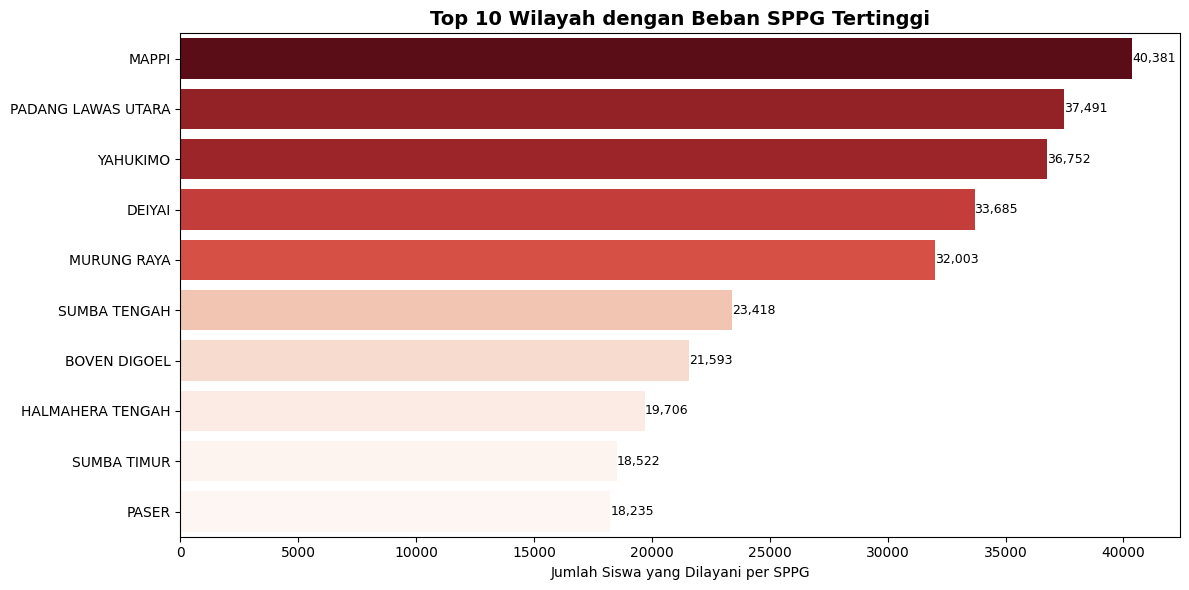

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

top10 = (df_final[df_final["jumlah_sppg"] > 0].sort_values("rasio_siswa_per_sppg", ascending=False).head(10))
plt.figure(figsize=(12,6))
ax = sns.barplot(data=top10, y="nama_kabupaten", x="rasio_siswa_per_sppg", hue="rasio_siswa_per_sppg", palette="Reds", legend=False)

for i, v in enumerate(top10["rasio_siswa_per_sppg"]):
    ax.text(v, i, f"{v:,.0f}", va="center", fontsize=9)
plt.title("Top 10 Wilayah dengan Beban SPPG Tertinggi", fontsize=14, weight="bold")

plt.xlabel("Jumlah Siswa yang Dilayani per SPPG")
plt.ylabel("")
plt.tight_layout()
plt.show()

Wilayah dengan rasio tertinggi menunjukkan bahwa satu fasilitas SPPG harus melayani jumlah siswa yang sangat besar, sehingga wilayah tersebut menjadi prioritas utama untuk penambahan fasilitas.

## 2. Apakah distribusi SPPG sudah sebanding dengan jumlah siswa?

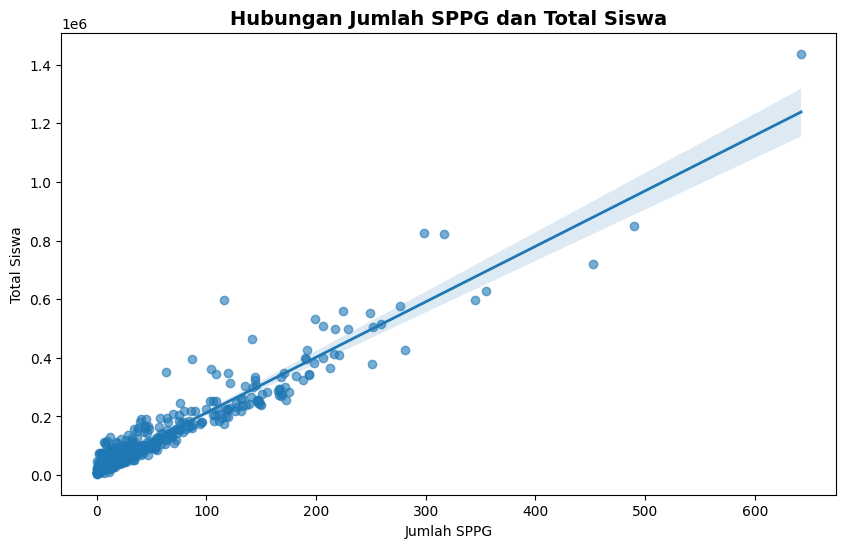

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(data=df_final, x="jumlah_sppg", y="total_siswa", scatter_kws={"alpha":0.6}, line_kws={"linewidth":2})
plt.title("Hubungan Jumlah SPPG dan Total Siswa", fontsize=14, weight="bold")

plt.xlabel("Jumlah SPPG")
plt.ylabel("Total Siswa")
plt.show()

Semakin banyak jumlah siswa pada suatu kabupaten/kota, semakin banyak pula jumlah SPPG yang tersedia. Namun masih terdapat beberapa wilayah yang berada jauh di atas garis tren, yang mengindikasikan kebutuhan tambahan SPPG lebih tinggi dibanding wilayah lain dengan jumlah siswa yang serupa.

## 3. Wilayah mana yang membutuhkan tambahan SPPG paling banyak (gap tertinggi)?

### Distribusi Rasio Siswa per SPPG

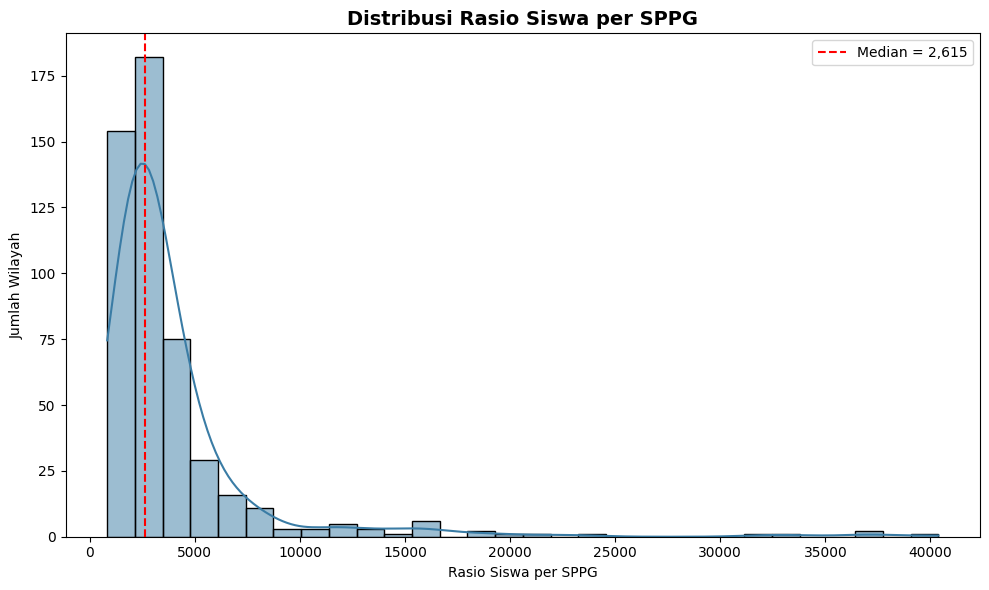

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df_final["rasio_siswa_per_sppg"], bins=30, kde=True, color="#3A7CA5")
plt.axvline(df_final["rasio_siswa_per_sppg"].median(), color="red", linestyle="--",
            label=f"Median = {df_final['rasio_siswa_per_sppg'].median():,.0f}")
plt.legend()
plt.title("Distribusi Rasio Siswa per SPPG", fontsize=14, weight="bold")
plt.xlabel("Rasio Siswa per SPPG")
plt.ylabel("Jumlah Wilayah")
plt.tight_layout()
plt.show()

Grafik histogram menunjukkan bahwa distribusi rasio siswa per SPPG tidak merata (right-skewed / miring ke kanan). Sebagian besar kabupaten/kota memiliki rasio di kisaran 2.000–5.000 siswa per SPPG, yang bisa dianggap sebagai kondisi “umum”. Namun, terdapat sejumlah wilayah dengan rasio yang sangat tinggi (hingga >40.000), yang muncul sebagai outlier di sisi kanan grafik.

Hal ini menunjukkan bahwa:

- Sebagian besar wilayah sudah memiliki distribusi SPPG yang relatif cukup, walaupun belum tentu ideal.
- Beberapa wilayah mengalami kekurangan SPPG yang sangat signifikan, ditandai dengan rasio yang ekstrem tinggi.
- Distribusi yang tidak seimbang ini mengindikasikan adanya ketimpangan akses fasilitas SPPG antar wilayah.

> **Benchmark:** Nilai `kebutuhan_sppg = total_siswa / 3.000` berdasarkan Juknis BGN (Agustus 2025) — 1 SPPG melayani rata-rata 3.000 siswa.



/tmp/ipykernel_10942/3511294927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_gap, y="nama_kabupaten", x="gap_sppg", palette="Reds_r")


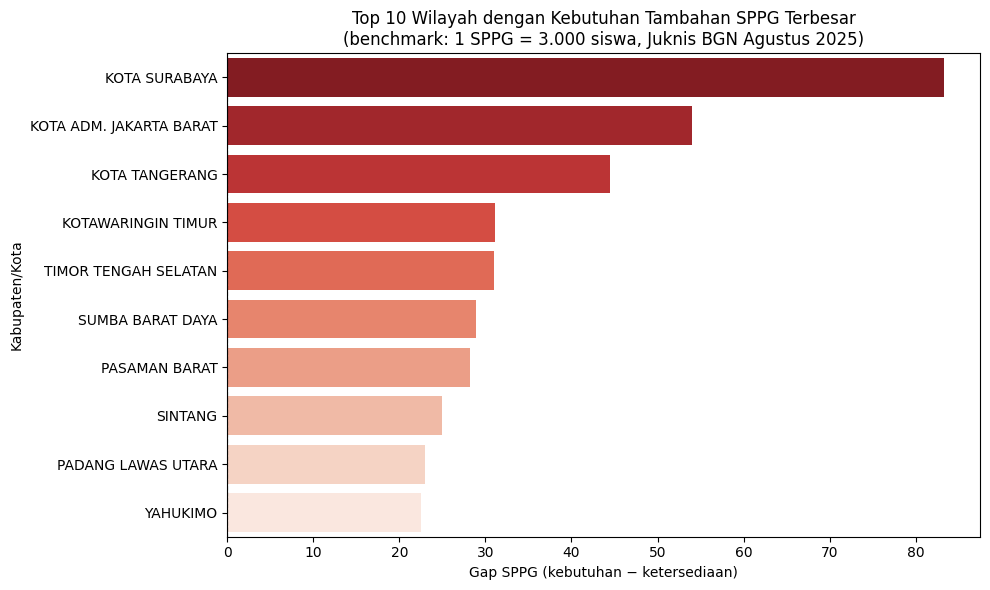

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_gap, y="nama_kabupaten", x="gap_sppg", palette="Reds_r")
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Top 10 Wilayah dengan Kebutuhan Tambahan SPPG Terbesar\n(benchmark: 1 SPPG = 3.000 siswa, Juknis BGN Agustus 2025)")
plt.xlabel("Gap SPPG (kebutuhan − ketersediaan)")
plt.ylabel("Kabupaten/Kota")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

Analisis gap juga memperkuat bahwa wilayah-wilayah tersebut menjadi prioritas utama untuk penambahan fasilitas SPPG guna mencapai distribusi yang lebih adil dan efektif.

## 4. Bagaimana proporsi siswa per jenjang (SD, SMP, SMA, SMK) pada wilayah-wilayah dengan jumlah SPPG terbanyak?

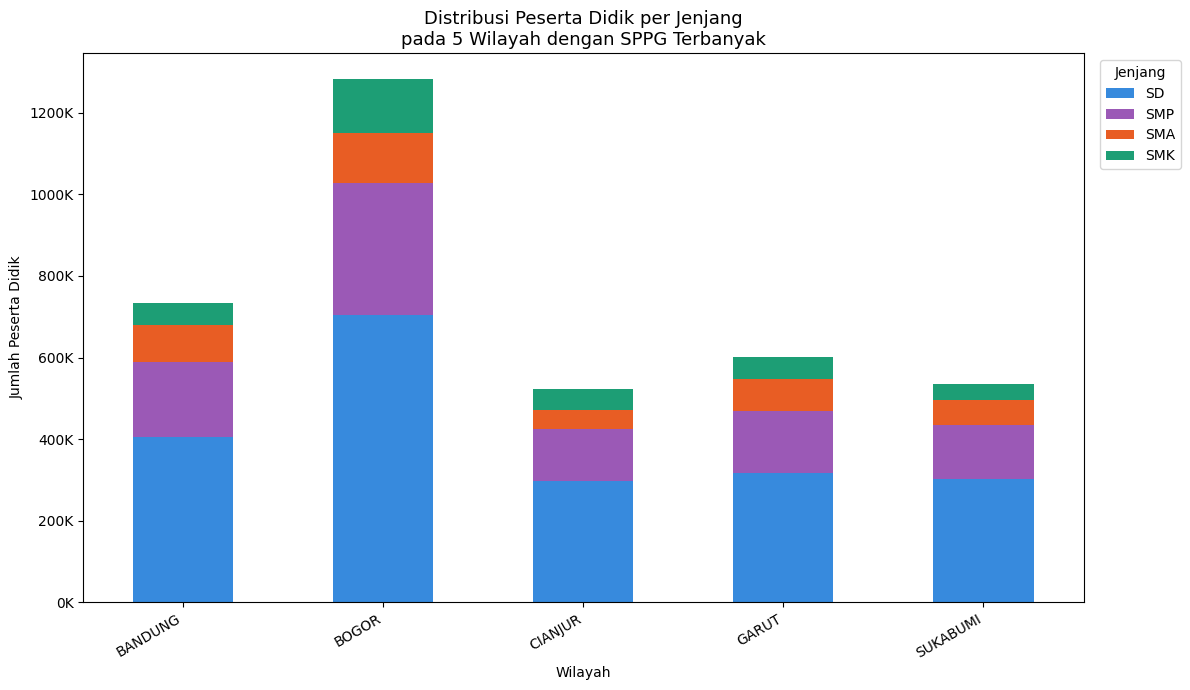

In [ ]:
top5_wilayah = df_sppg_kab.nlargest(5, "jumlah_sppg")["nama_kabupaten"]
df_proporsi  = df_final[df_final["nama_kabupaten"].isin(top5_wilayah)]

df_jenjang = df_proporsi.groupby("nama_kabupaten").agg(
    SD=("sd_sederajat",  "first"),
    SMP=("smp_sederajat", "first"),
    SMA=("sma_sederajat", "first"),
    SMK=("smk_sederajat", "first")
).reset_index()

df_plot = df_jenjang.set_index("nama_kabupaten")

fig, ax = plt.subplots(figsize=(12, 7))
df_plot.plot(kind="bar", stacked=True, ax=ax,
             color=["#378ADD", "#9b59b6", "#E85D24", "#1D9E75"])
ax.set_title("Distribusi Peserta Didik per Jenjang\npada 5 Wilayah dengan SPPG Terbanyak",
             fontsize=13)
ax.set_xlabel("Wilayah")
ax.set_ylabel("Jumlah Peserta Didik")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(title="Jenjang", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Interpretasi grafik tersebut menunjukkan bahwa jenjang SD Sederajat mendominasi jumlah siswa di seluruh wilayah pusat SPPG, yang mengindikasikan tingginya beban operasional pada tingkat pendidikan dasar. Meskipun jumlah siswa SMA dan SMK lebih sedikit, proporsinya tetap signifikan dan bervariasi, sehingga memerlukan spesialisasi layanan yang berbeda sesuai kebutuhan teknis masing-masing wilayah. Data ini menjadi dasar strategis bagi pengelola untuk memprioritaskan penambahan kapasitas layanan atau personil di wilayah dengan kepadatan siswa tertinggi guna menjaga efektivitas program SPPG.

## 5. Apakah ketersediaan jumlah SPPG saat ini sudah berkorelasi positif dengan pertumbuhan jumlah siswa SMA dan SMK?

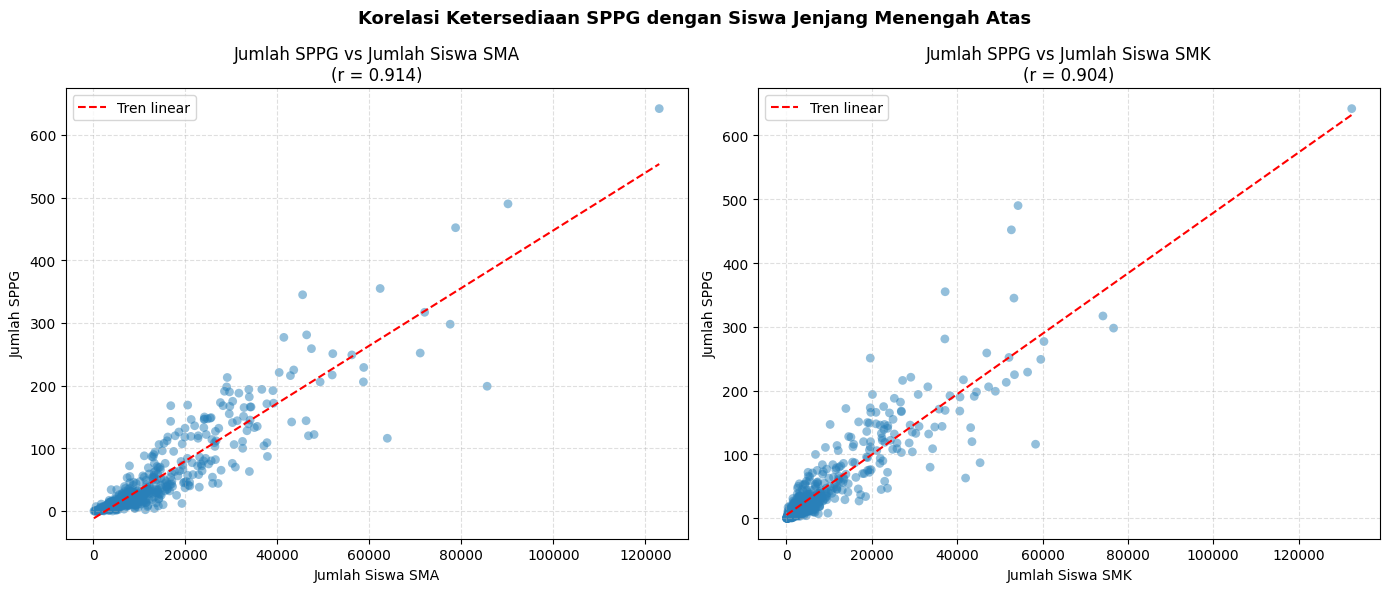

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, label in [
    (axes[0], "sma_sederajat", "Jumlah Siswa SMA"),
    (axes[1], "smk_sederajat", "Jumlah Siswa SMK"),
]:
    ax.scatter(df_final[col], df_final["jumlah_sppg"],
               alpha=0.5, s=40, color="#2980b9", edgecolors="none")
    # Garis tren
    mask = df_final[col].notna() & df_final["jumlah_sppg"].notna()
    z = np.polyfit(df_final.loc[mask, col], df_final.loc[mask, "jumlah_sppg"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_final[col].min(), df_final[col].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label="Tren linear")
    corr = df_final[[col, "jumlah_sppg"]].corr().iloc[0, 1]
    ax.set_title(f"Jumlah SPPG vs {label}\n(r = {corr:.3f})")
    ax.set_xlabel(label)
    ax.set_ylabel("Jumlah SPPG")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Korelasi Ketersediaan SPPG dengan Siswa Jenjang Menengah Atas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Visualisasi tersebut menunjukkan hubungan antara jumlah siswa SMA dengan jumlah siswa SMK di berbagai wilayah, di mana ukuran serta intensitas warna lingkaran mewakili banyaknya titik SPPG yang tersedia. Secara keseluruhan, terlihat adanya korelasi positif di mana wilayah dengan populasi siswa SMA yang tinggi cenderung memiliki populasi siswa SMK yang tinggi pula, namun persebaran ukuran lingkaran yang tidak seragam menunjukkan bahwa ketersediaan titik SPPG belum sepenuhnya merata mengikuti kepadatan jumlah siswa di jenjang menengah tersebut. Fenomena ini mengindikasikan adanya wilayah-wilayah tertentu yang memiliki beban pelayanan tinggi dengan jumlah fasilitas SPPG yang masih relatif minim, sehingga titik-titik tersebut menjadi prioritas strategis untuk pengembangan infrastruktur atau penambahan layanan di masa depan.

## 6. Wilayah mana saja yang dikategorikan sebagai 'Prioritas Utama' (High Demand, Low Supply) dibandingkan dengan wilayah 'Layanan Sesuai'?

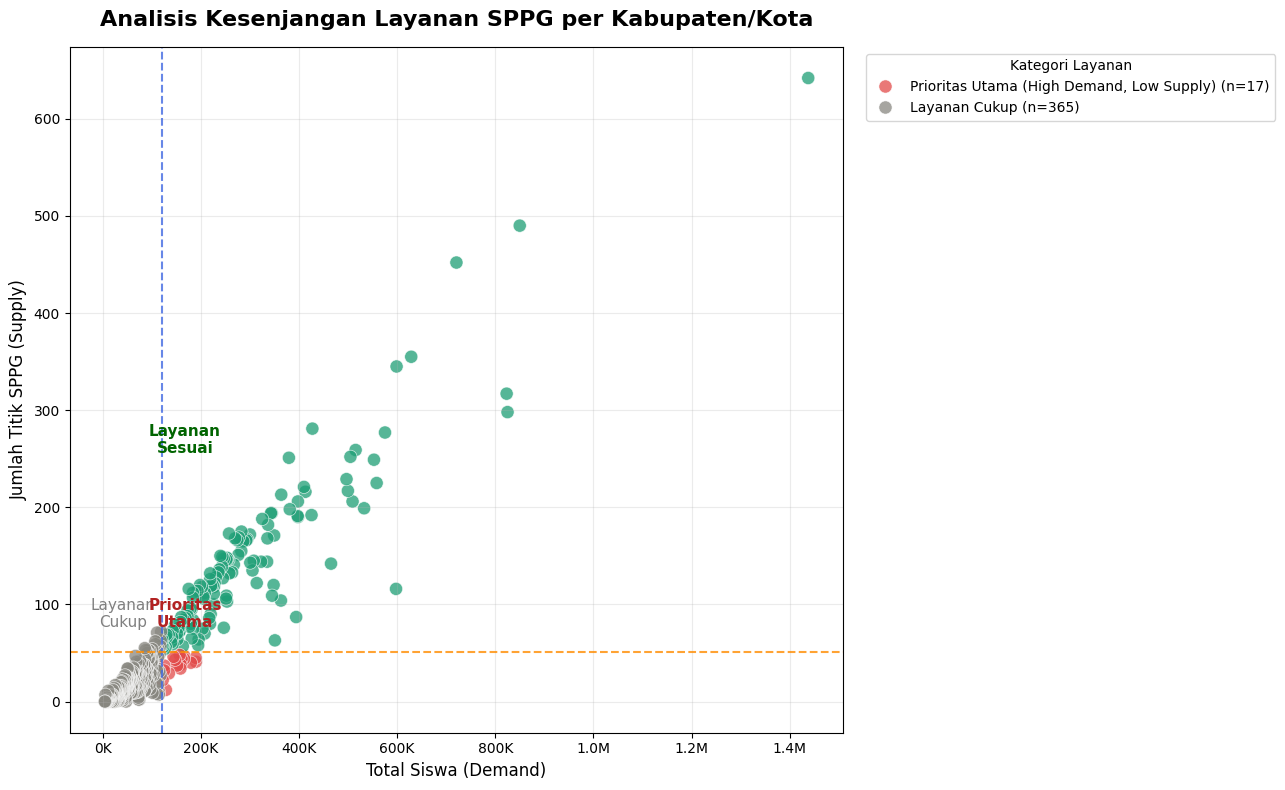

In [ ]:
palette = {
    "Prioritas Utama (High Demand, Low Supply)": "#E24B4A",
    "Layanan Sesuai (High Demand, High Supply)": "#1D9E75",
    "Layanan Cukup": "#888780"
}

# Hitung jumlah wilayah per kategori
jumlah_kategori = df_final["kategori_layanan"].value_counts()
fig, ax = plt.subplots(figsize=(13, 8))
sns.scatterplot(data=df_final, x="total_siswa", y="jumlah_sppg", hue="kategori_layanan", palette=palette,
                s=90, alpha=0.75, edgecolor="white", linewidth=0.5, ax=ax) # PERBAIKAN: 'total' → 'total_siswa'
# Garis rata-rata
ax.axvline(mean_siswa, color="royalblue", linestyle="--", linewidth=1.5, alpha=0.8)
ax.axhline(mean_sppg, color="darkorange", linestyle="--", linewidth=1.5, alpha=0.8)
# Label kuadran
ax.text( mean_siswa * 0.35, mean_sppg * 1.5, "Layanan\nCukup", fontsize=11, color="gray", ha="center")
ax.text(mean_siswa * 1.4, mean_sppg * 1.5, "Prioritas\nUtama", fontsize=11, color="#B22222", fontweight="bold", ha="center")
ax.text(mean_siswa * 1.4, mean_sppg * 5, "Layanan\nSesuai", fontsize=11, color="#006400", fontweight="bold", ha="center")
# Format sumbu X
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M"
        if x >= 1e6 else f"{x/1e3:.0f}K"
    )
)
# Judul
ax.set_title("Analisis Kesenjangan Layanan SPPG per Kabupaten/Kota", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Total Siswa (Demand)", fontsize=12)
ax.set_ylabel("Jumlah Titik SPPG (Supply)", fontsize=12)
# Legend dengan jumlah wilayah
handles, labels = ax.get_legend_handles_labels()
labels_baru = []
for label in labels[1:]:
    labels_baru.append(
        f"{label} (n={jumlah_kategori[label]})"
    )
ax.legend(handles[1:], labels_baru, title="Kategori Layanan", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Visualisasi kuadran ini membagi wilayah menjadi beberapa zona berdasarkan kapasitas layanan terhadap jumlah siswa, di mana garis putus-putus mewakili rata-rata nasional untuk masing-masing variabel. Wilayah yang berada di kuadran kanan bawah (berwarna merah) diidentifikasi sebagai zona prioritas utama karena memiliki jumlah peserta didik yang tinggi namun didukung oleh titik SPPG yang masih di bawah rata-rata. Pola ini mengonfirmasi adanya kesenjangan distribusi fasilitas yang signifikan, sehingga pengambil kebijakan dapat menjadikan titik-titik di area merah tersebut sebagai lokasi utama untuk rencana ekspansi infrastruktur layanan pendidikan guna mencapai pemerataan akses yang lebih optimal.

## Kesiapan Data (Summary)

In [ ]:
print("=" * 55)
print("PEMERIKSAAN KESIAPAN DATA")
print("=" * 55)

print("\n1. Duplikasi berdasarkan kode_wilayah:")
print(f"   {df_final['kode_wilayah'].duplicated().sum()} duplikat")

print("\n2. Potensi data leakage:")
print("   ⚠ Kolom 'total' dan 'total_siswa' adalah kolom yang sama.")
print("   → Jika keduanya masuk sebagai fitur model, terjadi data leakage.")
print("   → Solusi: gunakan hanya 'total_siswa', drop kolom 'total' sebelum modeling.")

print("\n3. Kolom kategorik yang perlu dienkode:")
cat_cols = df_final.select_dtypes(include='object').columns.tolist()
print(f"   {cat_cols}")
print("   → Gunakan LabelEncoder atau OneHotEncoder sebelum dimasukkan ke model.")

print("\n4. Distribusi kategori target (kategori_layanan):")
print(df_final['kategori_layanan'].value_counts().to_string())

PEMERIKSAAN KESIAPAN DATA

1. Duplikasi berdasarkan kode_wilayah:
   0 duplikat

2. Potensi data leakage:
   ⚠ Kolom 'total' dan 'total_siswa' adalah kolom yang sama.
   → Jika keduanya masuk sebagai fitur model, terjadi data leakage.
   → Solusi: gunakan hanya 'total_siswa', drop kolom 'total' sebelum modeling.

3. Kolom kategorik yang perlu dienkode:
   ['kode_wilayah', 'nama_wilayah', 'nama_kabupaten', 'kode_provinsi', 'kode_kabupaten', 'kategori_layanan']
   → Gunakan LabelEncoder atau OneHotEncoder sebelum dimasukkan ke model.

4. Distribusi kategori target (kategori_layanan):
kategori_layanan
Layanan Cukup                                365
Layanan Sesuai (High Demand, High Supply)    132
Prioritas Utama (High Demand, Low Supply)     17


In [ ]:
# Simpan dataset final yang siap untuk modeling
# Hapus kolom 'total' untuk mencegah data leakage dengan 'total_siswa'
cols_model = [
    "kode_wilayah", "kode_provinsi", "kode_kabupaten", "nama_kabupaten",
    "sd_sederajat", "smp_sederajat", "sma_sederajat", "smk_sederajat",
    "total_siswa",
    "jumlah_sppg", "flag_tanpa_sppg",
    "rasio_siswa_per_sppg",
    "kebutuhan_sppg", "gap_sppg",
    "kategori_layanan"
]

df_model = df_final[cols_model].copy()

print("Dataset final siap modeling:")
print(f"  Shape : {df_model.shape}")
print(f"  Kolom : {df_model.columns.tolist()}")
df_model.head()

Dataset final siap modeling:
  Shape : (514, 15)
  Kolom : ['kode_wilayah', 'kode_provinsi', 'kode_kabupaten', 'nama_kabupaten', 'sd_sederajat', 'smp_sederajat', 'sma_sederajat', 'smk_sederajat', 'total_siswa', 'jumlah_sppg', 'flag_tanpa_sppg', 'rasio_siswa_per_sppg', 'kebutuhan_sppg', 'gap_sppg', 'kategori_layanan']


,kode_wilayah,kode_provinsi,kode_kabupaten,nama_kabupaten,sd_sederajat,smp_sederajat,sma_sederajat,smk_sederajat,total_siswa,jumlah_sppg,flag_tanpa_sppg,rasio_siswa_per_sppg,kebutuhan_sppg,gap_sppg,kategori_layanan
0,20500,20,2050,BOGOR,703051,323841,123027,132446,1437666,642.0,0,2239.355140,479.222000,-162.778000,"Layanan Sesuai (High Demand, High Supply)"
1,20800,20,2080,BANDUNG,405286,184351,90140,54268,849908,490.0,0,1734.506122,283.302667,-206.697333,"Layanan Sesuai (High Demand, High Supply)"
2,280300,28,2803,TANGERANG,417022,174765,77573,76649,825053,298.0,0,2768.634228,275.017667,-22.982333,"Layanan Sesuai (High Demand, High Supply)"
3,22200,22,2220,BEKASI,423093,169132,72021,74158,823184,317.0,0,2596.794953,274.394667,-42.605333,"Layanan Sesuai (High Demand, High Supply)"
4,21100,21,2110,GARUT,316304,152613,78744,52705,720917,452.0,0,1594.949115,240.305667,-211.694333,"Layanan Sesuai (High Demand, High Supply)"


In [ ]:
# Ekspor ke CSV
output_final = "/content/drive/MyDrive/Dataset_Capstone/Dataset_Capstone_Final.csv"
df_model.to_csv(output_final, index=False)
print(f"Dataset final tersimpan di:\n{output_final}")

Dataset final tersimpan di:
/content/drive/MyDrive/Dataset_Capstone/Dataset_Capstone_Final.csv


# Kesimpulan
- Identifikasi Ketimpangan Layanan: Analisis data menunjukkan bahwa terdapat variasi yang cukup besar dalam rasio beban siswa terhadap jumlah titik SPPG antarwilayah. Banyak wilayah yang memiliki konsentrasi peserta didik tinggi namun belum didukung oleh jumlah fasilitas layanan yang memadai.
- Dominasi Segmen Pendidikan Dasar: Secara kuantitas, jenjang SD Sederajat merupakan kontributor utama jumlah peserta didik di hampir seluruh pusat layanan. Hal ini menuntut adanya prioritas alokasi sumber daya pada jenjang pendidikan dasar untuk menjaga efektivitas layanan bagi populasi siswa terbesar.
- Pentingnya Spesialisasi Jenjang Menengah: Meskipun jumlahnya lebih sedikit dibandingkan jenjang SD, komposisi siswa SMA dan SMK yang signifikan di beberapa wilayah strategis menunjukkan kebutuhan akan layanan yang lebih spesifik, seperti pelatihan teknis atau pengembangan karir yang sesuai dengan kurikulum kejuruan (SMK).
- Validasi Prioritas Strategis: Melalui analisis kuadran layanan, telah berhasil dipetakan wilayah-wilayah yang masuk kategori "Prioritas Utama" (wilayah dengan kepadatan siswa tinggi namun memiliki jumlah SPPG rendah). Wilayah-wilayah ini merupakan kandidat lokasi paling mendesak untuk rencana ekspansi atau penambahan titik layanan baru.
- Pentingnya Pendekatan Berbasis Data: Penggabungan dan pembersihan dataset berhasil mengubah data mentah menjadi wawasan operasional yang konkret. Pendekatan ini membuktikan bahwa pengambilan keputusan untuk kebijakan publik atau pengembangan infrastruktur harus didasarkan pada korelasi antara demand (kepadatan siswa) dan supply (titik layanan) untuk mencapai pemerataan akses pendidikan.